In [49]:
import os
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

print("Environment configured successfully.")

Environment configured successfully.


In [50]:
# Set path to your workspace directory
TARGET_FILE = "metrics_n8_1e-3.csv"  # Switch to metrics_n16.csv or metrics_n8.csv as needed
WORKSPACE = Path.home() / "bicycle-architecture-compiler"

csv_path = (WORKSPACE / TARGET_FILE) if (WORKSPACE / TARGET_FILE).exists() else Path(TARGET_FILE)
df = pd.read_csv(csv_path)

# Display overview and column types
df.info()
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   adder              25 non-null     str    
 1   partition          25 non-null     str    
 2   allocated_qubits   25 non-null     int64  
 3   code               25 non-null     str    
 4   noise_model        25 non-null     str    
 5   pbc_steps          25 non-null     int64  
 6   measurement_depth  25 non-null     int64  
 7   end_time           25 non-null     int64  
 8   total_error        25 non-null     float64
 9   failure_prob       25 non-null     float64
 10  automorphisms      25 non-null     int64  
 11  measurements       25 non-null     int64  
dtypes: float64(2), int64(6), str(4)
memory usage: 2.5 KB


,adder,partition,allocated_qubits,code,noise_model,pbc_steps,measurement_depth,end_time,total_error,failure_prob,automorphisms,measurements
0,sklansky_n8,original,36,two-gross,two-gross_1e-3,178,1704,396096,5.564076e-07,5.564076e-07,6,12
1,sklansky_n8,weighted_degree,36,two-gross,two-gross_1e-3,178,1723,400584,5.565977e-07,5.565977e-07,6,12
2,sklansky_n8,metis,36,two-gross,two-gross_1e-3,178,1706,396528,5.564176e-07,5.564176e-07,2,7
3,sklansky_n8,kahypar,36,two-gross,two-gross_1e-3,178,1712,397920,5.564876e-07,5.564876e-07,6,12
4,sklansky_n8,clustering,36,two-gross,two-gross_1e-3,178,1713,398136,5.564976e-07,5.564976e-07,6,12


In [51]:
# Normalize column types
numeric_cols = ["measurement_depth", "end_time", "total_error", "automorphisms", "measurements"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col])

# Calculate differences relative to the unpartitioned 'original' baseline
augmented_rows = []

for adder_name, group in df.groupby("adder"):
    orig_rows = group[group["partition"] == "original"]
    if orig_rows.empty:
        continue
    
    orig = orig_rows.iloc[0]
    orig_depth = orig["measurement_depth"]
    orig_time = orig["end_time"]
    
    for _, row in group.iterrows():
        r = row.to_dict()
        
        # Absolute and percentage savings (negative indicates reduction/improvement)
        r["depth_diff"] = row["measurement_depth"] - orig_depth
        r["depth_pct"] = (r["depth_diff"] / orig_depth) * 100
        r["time_diff"] = row["end_time"] - orig_time
        r["time_pct"] = (r["time_diff"] / orig_time) * 100
        r["delta_cycles"] = r["end_time"] - orig["end_time"]
        r["pct_cycles"] = (r["delta_cycles"] / orig["end_time"]) * 100
        r["delta_depth"] = r["measurement_depth"] - orig["measurement_depth"]
        r["pct_depth"] = (r["delta_depth"] / orig["measurement_depth"]) * 100
        r["cycles_per_pbc_step"] = r["end_time"] / r["pbc_steps"]
        r["cycles_per_depth_layer"] = r["end_time"] / r["measurement_depth"]
        r["clean_adder"] = r["adder"].split("_n")[0].replace("_", " ").title()
        
        augmented_rows.append(r)

df_analysis = pd.DataFrame(augmented_rows)

# Display tabular summary sorted by physical cycle savings
summary_cols = ["adder", "partition", "measurement_depth", "depth_diff", "end_time", "time_diff", "time_pct", "automorphisms", "measurements"]
display(df_analysis[summary_cols].sort_values(by=["adder", "time_diff"]))

,adder,partition,measurement_depth,depth_diff,end_time,time_diff,time_pct,automorphisms,measurements
3,brent_kung_n8,kahypar,1481,-7,344136,-1704,-0.492713,6,12
4,brent_kung_n8,clustering,1482,-6,344448,-1392,-0.402498,6,12
0,brent_kung_n8,original,1488,0,345840,0,0.000000,6,12
2,brent_kung_n8,metis,1488,0,345840,0,0.000000,6,12
1,brent_kung_n8,weighted_degree,1499,11,348504,2664,0.770298,12,12
9,han_carlson_n8,clustering,1622,-21,377040,-4824,-1.263277,6,12
8,han_carlson_n8,kahypar,1628,-15,378432,-3432,-0.898749,6,12
6,han_carlson_n8,weighted_degree,1631,-12,379080,-2784,-0.729055,6,12
7,han_carlson_n8,metis,1636,-7,380160,-1704,-0.446232,6,12
5,han_carlson_n8,original,1643,0,381864,0,0.000000,6,12


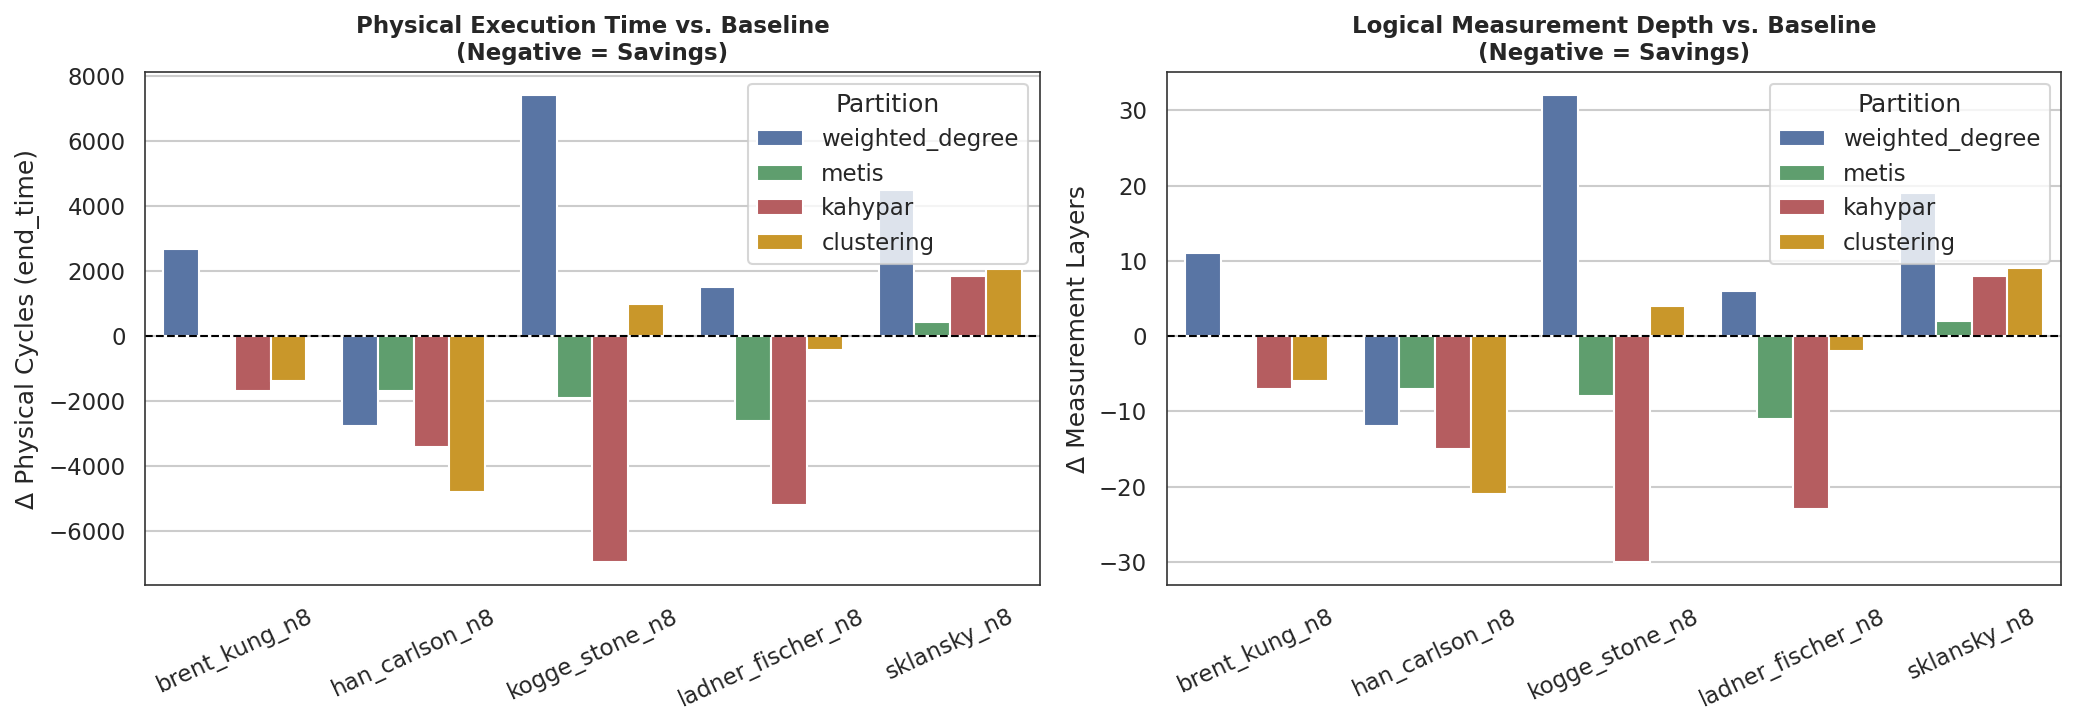

In [52]:
# Filter out the baseline so plots highlight deltas directly
plot_df = df_analysis[df_analysis["partition"] != "original"].copy()

if plot_df.empty:
    print("No non-baseline partition data available to plot.")
else:
    order_schemes = ["weighted_degree", "metis", "kahypar", "clustering"]
    palette = {"weighted_degree": "#4C72B0", "metis": "#55A868", "kahypar": "#C44E52", "clustering": "#E4A10F"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Physical Runtime Cycle Savings
    sns.barplot(
        data=plot_df,
        x="adder",
        y="time_diff",
        hue="partition",
        hue_order=order_schemes,
        palette=palette,
        ax=axes[0]
    )
    axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title("Physical Execution Time vs. Baseline\n(Negative = Savings)", fontsize=11, fontweight="bold")
    axes[0].set_ylabel("Δ Physical Cycles (end_time)")
    axes[0].set_xlabel("")
    axes[0].tick_params(axis="x", rotation=25)
    axes[0].legend(title="Partition")

    # 2. Logical Measurement Depth Savings
    sns.barplot(
        data=plot_df,
        x="adder",
        y="depth_diff",
        hue="partition",
        hue_order=order_schemes,
        palette=palette,
        ax=axes[1]
    )
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("Logical Measurement Depth vs. Baseline\n(Negative = Savings)", fontsize=11, fontweight="bold")
    axes[1].set_ylabel("Δ Measurement Layers")
    axes[1].set_xlabel("")
    axes[1].tick_params(axis="x", rotation=25)
    axes[1].legend(title="Partition")

    plt.tight_layout()
    plt.show()

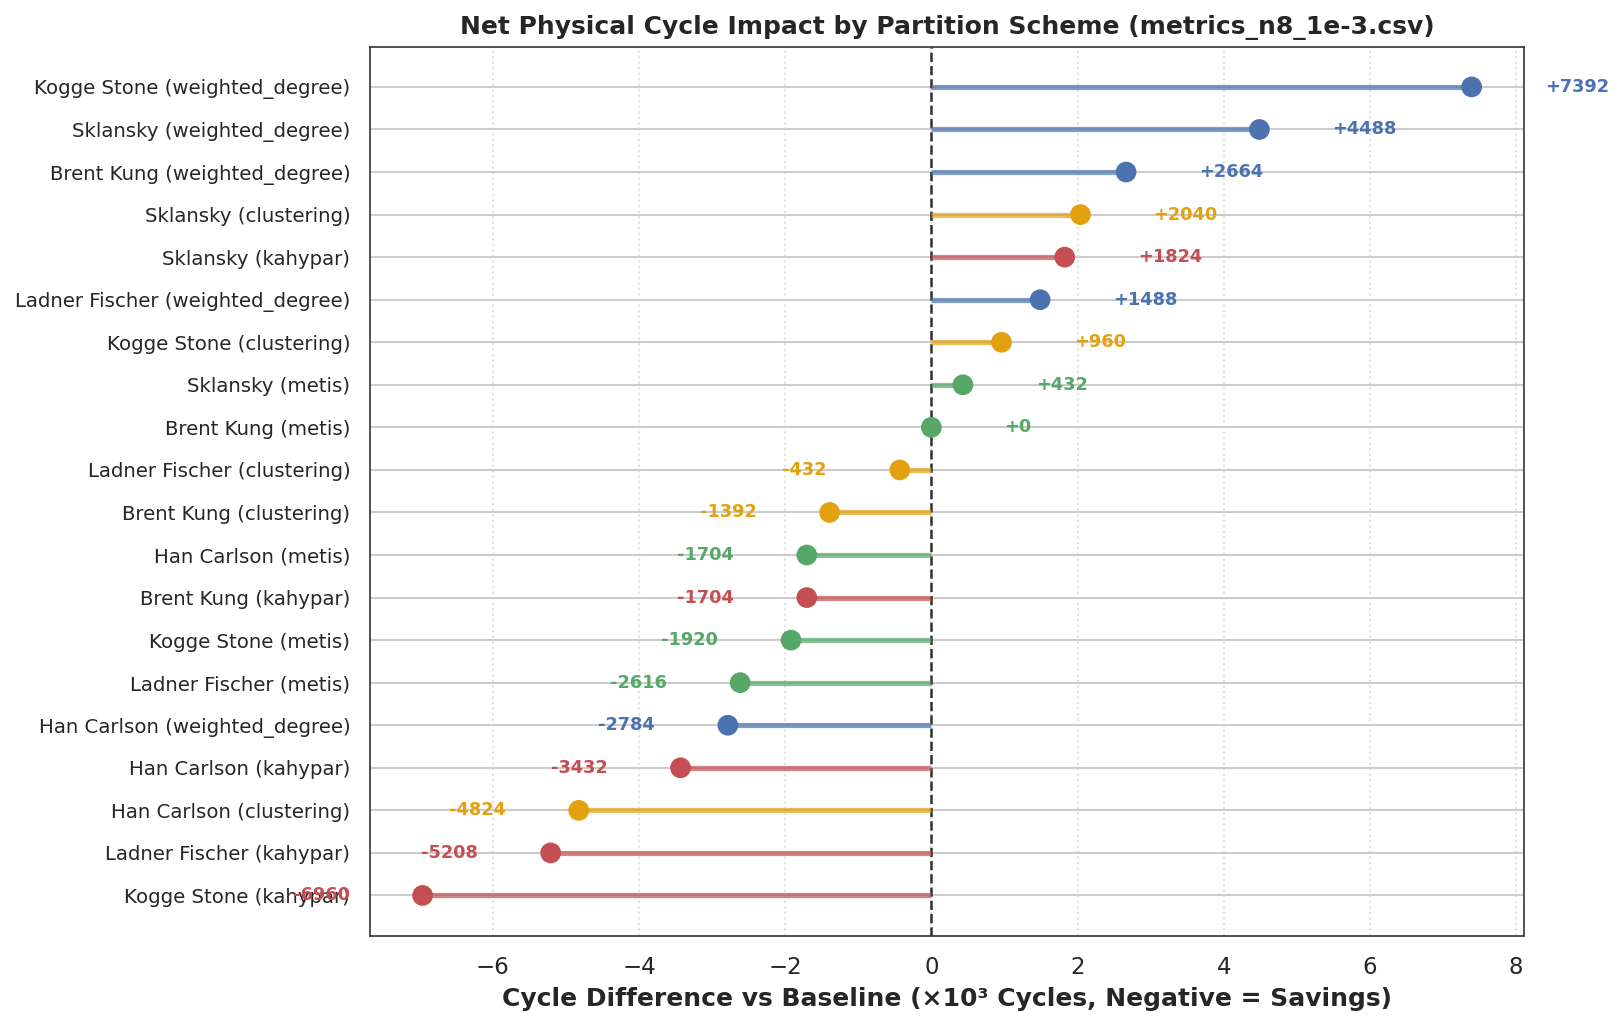

In [53]:
non_orig = df_analysis[df_analysis["partition"] != "original"].copy()
non_orig["config_label"] = non_orig["clean_adder"] + " (" + non_orig["partition"] + ")"
non_orig = non_orig.sort_values("delta_cycles", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))

scheme_colors = {"weighted_degree": "#4C72B0", "metis": "#55A868", "kahypar": "#C44E52", "clustering": "#E4A10F"}
bar_colors = [scheme_colors.get(p, "#888888") for p in non_orig["partition"]]
y_positions = np.arange(len(non_orig))

# Draw baseline and stems
ax.axvline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
ax.hlines(y=y_positions, xmin=0, xmax=non_orig["delta_cycles"] / 1000.0, color=bar_colors, linewidth=2.5, alpha=0.7)
ax.scatter(non_orig["delta_cycles"] / 1000.0, y_positions, color=bar_colors, s=80, zorder=3)

# Label exact values
for idx, (y, val) in enumerate(zip(y_positions, non_orig["delta_cycles"])):
    ha = "left" if val >= 0 else "right"
    offset = 1.0 if val >= 0 else -1.0
    ax.text((val / 1000.0) + offset, y, f"{val:+d}", va="center", ha=ha, fontsize=8.5, fontweight="bold", color=bar_colors[idx])

ax.set_yticks(y_positions)
ax.set_yticklabels(non_orig["config_label"], fontsize=9.5)
ax.set_xlabel("Cycle Difference vs Baseline (×10³ Cycles, Negative = Savings)", fontweight="bold")
ax.set_title(f"Net Physical Cycle Impact by Partition Scheme ({TARGET_FILE})", fontweight="bold", fontsize=12)
ax.grid(axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

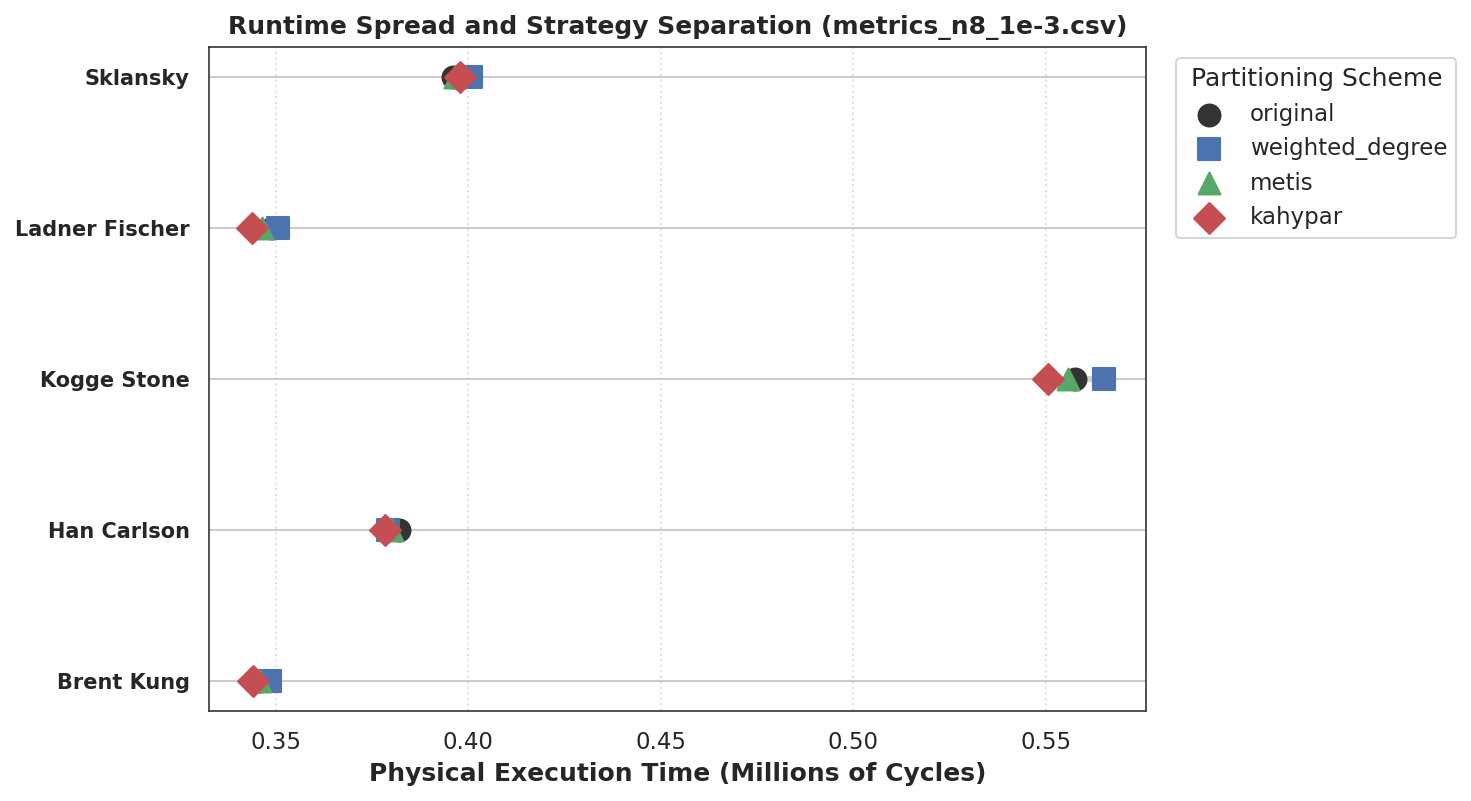

In [54]:
adder_order = df_analysis["clean_adder"].unique()
y_pos = np.arange(len(adder_order))

fig, ax = plt.subplots(figsize=(10, 5.5))

# Draw range connectors
for y, adder in zip(y_pos, adder_order):
    sub = df_analysis[df_analysis["clean_adder"] == adder]
    ax.hlines(y=y, xmin=sub["end_time"].min() / 1e6, xmax=sub["end_time"].max() / 1e6, color="lightgray", linewidth=3, zorder=1)

schemes = ["original", "weighted_degree", "metis", "kahypar"]
markers = {"original": "o", "weighted_degree": "s", "metis": "^", "kahypar": "D"}
palette = {"original": "#333333", "weighted_degree": "#4C72B0", "metis": "#55A868", "kahypar": "#C44E52", "clustering": "#E4A10F"}

for scheme in schemes:
    sub = df_analysis[df_analysis["partition"] == scheme].set_index("clean_adder").reindex(adder_order)
    ax.scatter(sub["end_time"] / 1e6, y_pos, label=scheme, marker=markers[scheme], color=palette[scheme], s=110, zorder=2)

ax.set_yticks(y_pos)
ax.set_yticklabels(adder_order, fontweight="bold", fontsize=10)
ax.set_xlabel("Physical Execution Time (Millions of Cycles)", fontweight="bold")
ax.set_title(f"Runtime Spread and Strategy Separation ({TARGET_FILE})", fontweight="bold", fontsize=12)
ax.legend(title="Partitioning Scheme", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3157/27606653.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


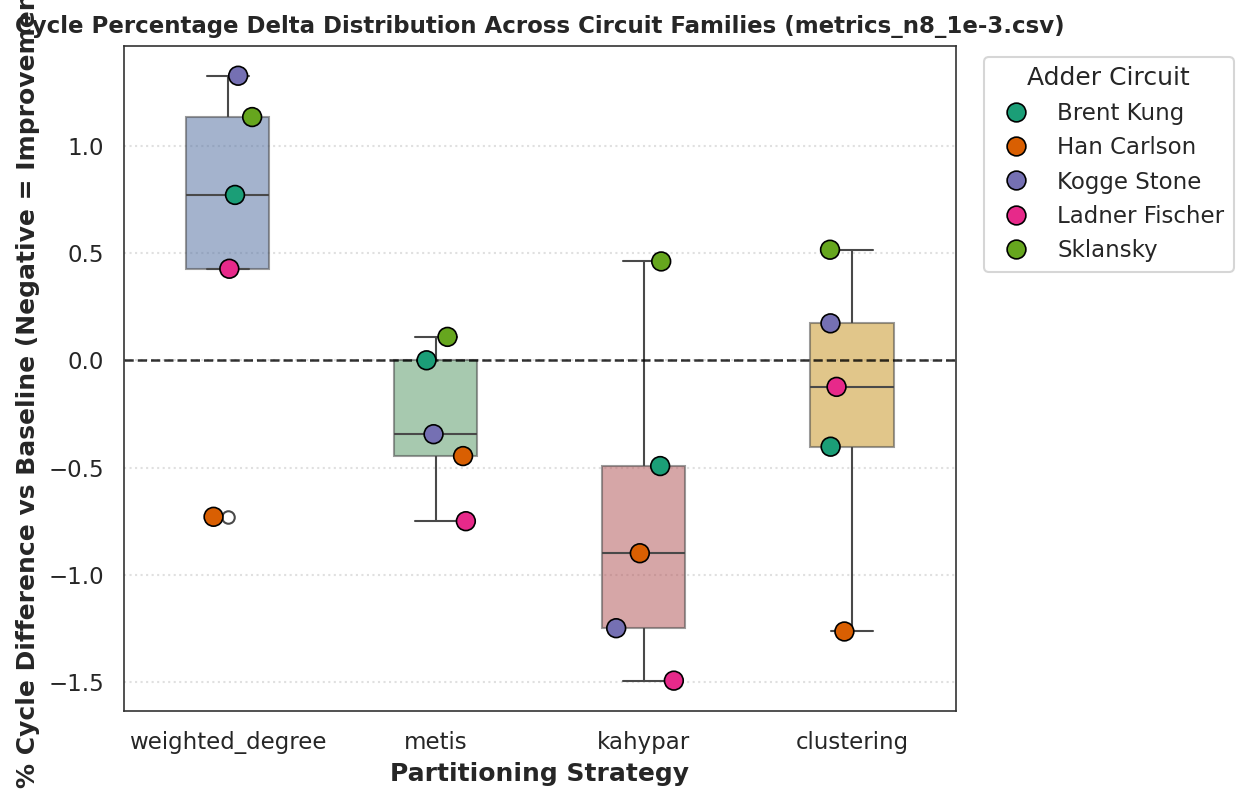

In [55]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))

order = ["weighted_degree", "metis", "kahypar", "clustering"]
scheme_palette = {"weighted_degree": "#4C72B0", "metis": "#55A868", "kahypar": "#C44E52", "clustering": "#E4A10F"}

sns.boxplot(
    data=df_analysis[df_analysis["partition"] != "original"],
    x="partition",
    y="pct_cycles",
    order=order,
    palette=scheme_palette,
    width=0.4,
    boxprops=dict(alpha=0.55),
    ax=ax
)

sns.stripplot(
    data=df_analysis[df_analysis["partition"] != "original"],
    x="partition",
    y="pct_cycles",
    order=order,
    hue="clean_adder",
    palette="Dark2",
    size=9,
    jitter=0.15,
    edgecolor="black",
    linewidth=0.8,
    ax=ax
)

ax.axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
ax.set_title(f"Cycle Percentage Delta Distribution Across Circuit Families ({TARGET_FILE})", fontweight="bold", fontsize=11)
ax.set_ylabel("% Cycle Difference vs Baseline (Negative = Improvement)", fontweight="bold")
ax.set_xlabel("Partitioning Strategy", fontweight="bold")
ax.legend(title="Adder Circuit", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

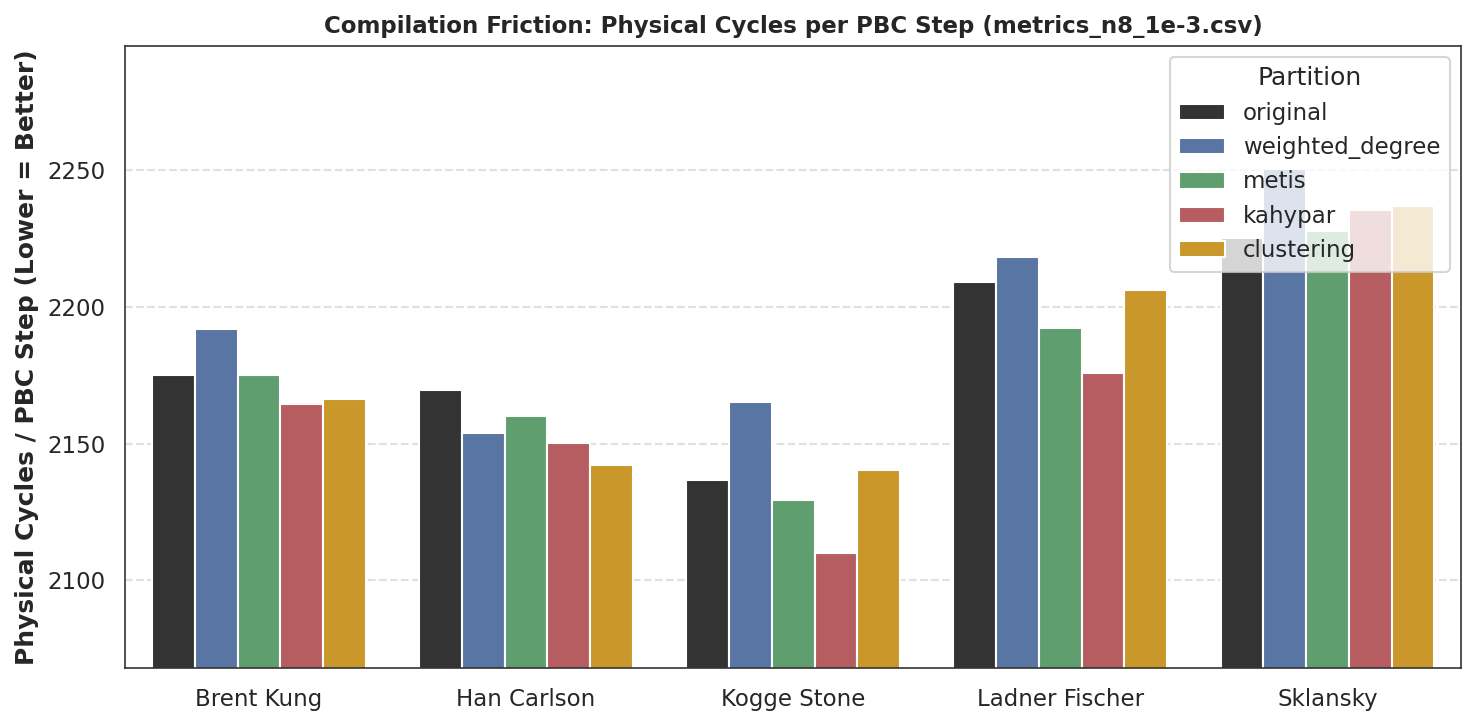

In [56]:
fig, ax = plt.subplots(figsize=(10, 5))

palette = {"original": "#333333", "weighted_degree": "#4C72B0", "metis": "#55A868", "kahypar": "#C44E52", "clustering": "#E4A10F"}

sns.barplot(
    data=df_analysis,
    x="clean_adder",
    y="cycles_per_pbc_step",
    hue="partition",
    palette=palette,
    ax=ax
)

# Focus y-axis on dynamic range
y_min = df_analysis["cycles_per_pbc_step"].min() * 0.98
y_max = df_analysis["cycles_per_pbc_step"].max() * 1.02
ax.set_ylim(y_min, y_max)

ax.set_title(f"Compilation Friction: Physical Cycles per PBC Step ({TARGET_FILE})", fontweight="bold", fontsize=11)
ax.set_ylabel("Physical Cycles / PBC Step (Lower = Better)", fontweight="bold")
ax.set_xlabel("")
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(title="Partition", loc="upper right")

plt.tight_layout()
plt.show()

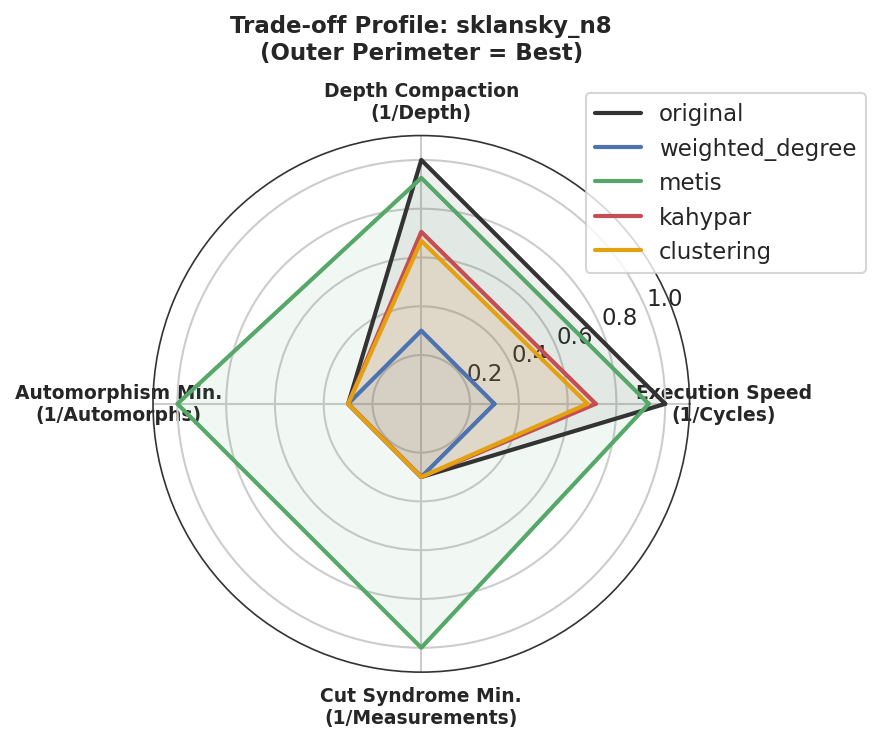

In [57]:
SELECTED_ADDER = "sklansky_n8"  # Change to any adder in your dataset

sub_df = df_analysis[df_analysis["adder"] == SELECTED_ADDER].copy()
if sub_df.empty:
    sub_df = df_analysis[df_analysis["adder"].str.contains("kogge_stone")].copy()

categories = ["Execution Speed\n(1/Cycles)", "Depth Compaction\n(1/Depth)", "Automorphism Min.\n(1/Automorphs)", "Cut Syndrome Min.\n(1/Measurements)"]
metrics_keys = ["end_time", "measurement_depth", "automorphisms", "measurements"]
N = len(categories)

# Invert metrics so lower hardware cost yields higher score
scores = {}
for k in metrics_keys:
    vals = sub_df[k].values
    min_v, max_v = vals.min(), vals.max()
    if max_v == min_v:
        scores[k] = {p: 1.0 for p in sub_df["partition"]}
    else:
        # Scale 0.3 to 1.0
        scores[k] = {p: 1.0 - 0.7 * (sub_df[sub_df["partition"] == p][k].values[0] - min_v) / (max_v - min_v) for p in sub_df["partition"]}

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw=dict(polar=True))
palette = {"original": "#333333", "weighted_degree": "#4C72B0", "metis": "#55A868", "kahypar": "#C44E52", "clustering": "#E4A10F"}

for p in ["original", "weighted_degree", "metis", "kahypar", "clustering"]:
    if p in sub_df["partition"].values:
        vals = [scores[k][p] for k in metrics_keys]
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=p, color=palette[p])
        ax.fill(angles, vals, color=palette[p], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9, fontweight="bold")
ax.set_ylim(0, 1.1)
ax.set_title(f"Trade-off Profile: {SELECTED_ADDER}\n(Outer Perimeter = Best)", fontweight="bold", fontsize=11, y=1.12)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))

plt.tight_layout()
plt.show()

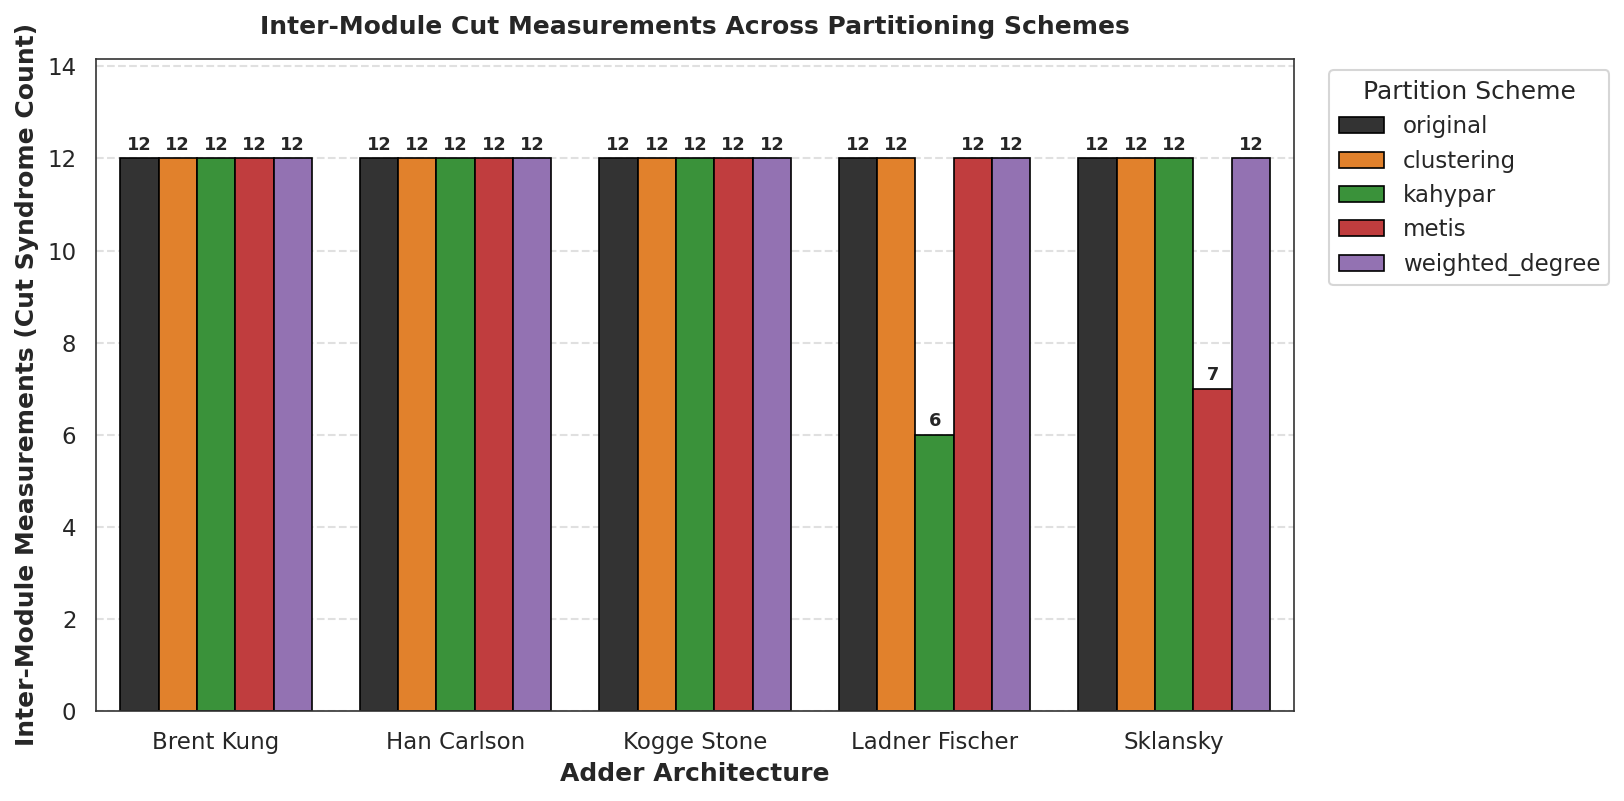

In [58]:
# 1. Acquire dataset (uses df or df_single from earlier cells, or loads metrics.csv directly)
source_df = df_analysis if 'df_analysis' in locals() else (df if 'df' in locals() else pd.read_csv("metrics.csv"))
plot_df = source_df.copy()

# Clean adder labels (e.g., "kogge_stone_n32" -> "Kogge Stone")
plot_df['clean_adder'] = (
    plot_df['adder']
    .str.replace(r'_n\d+', '', regex=True)
    .str.replace('_', ' ')
    .str.title()
)

# 2. Dynamically order partitions: keep 'original' first as baseline, followed by any existing or future schemes
available_partitions = list(plot_df['partition'].unique())
if 'original' in available_partitions:
    available_partitions.remove('original')
    partition_order = ['original'] + sorted(available_partitions)
else:
    partition_order = sorted(available_partitions)

# 3. Dynamic color palette (reserves dark slate #333333 for the baseline)
palette_colors = sns.color_palette("tab10", len(partition_order))
color_map = dict(zip(partition_order, palette_colors))
if 'original' in color_map:
    color_map['original'] = '#333333'

# 4. Render Grouped Bar Chart
fig, ax = plt.subplots(figsize=(11, 5.5))

sns.barplot(
    data=plot_df,
    x='clean_adder',
    y='measurements',
    hue='partition',
    hue_order=partition_order,
    palette=color_map,
    edgecolor='black',
    linewidth=0.8,
    ax=ax
)

# 5. Label integer measurement values directly on each bar
for p in ax.patches:
    h = p.get_height()
    if not np.isnan(h) and h > 0:
        ax.annotate(
            f"{int(h)}",
            (p.get_x() + p.get_width() / 2.0, h),
            ha='center',
            va='bottom',
            fontsize=8.5,
            fontweight='bold',
            xytext=(0, 2),
            textcoords='offset points'
        )

# 6. Styling & Layout
ax.set_title("Inter-Module Cut Measurements Across Partitioning Schemes", fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel("Inter-Module Measurements (Cut Syndrome Count)", fontweight='bold')
ax.set_xlabel("Adder Architecture", fontweight='bold')
ax.set_ylim(0, plot_df['measurements'].max() * 1.18)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(title="Partition Scheme", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()